In [1]:
from utils import get_match_df, analyze_strategies, get_best_leagues, get_best_strategies, compare_strategies

df = get_match_df()

df.tail()

/home/maicolnicolini/code/bet-master-analytics/src/strategies/utils.py:132: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  df_final = df_final[other_strategies_mask | dnb_mask]


,date,time,league,home_team,away_team,goal_home,goal_away,strategy,result,return,week
match_id,,,,,,,,,,,
d19429985,2026-04-07,16:45,Olanda B,FC Emmen,MVV Maastricht,2,1,Over 1.5 Optuna,True,0.35,14
d19429984,2026-04-07,16:45,Olanda B,De Graafschap,Jong AZ,5,0,Over 1.5 Optuna,True,0.35,14
d19429982,2026-04-07,16:45,Olanda B,ADO Den Haag,FC Eindhoven,4,0,Over 1.5 Optuna,True,0.35,14
d19503518,2026-04-07,17:30,Serie C: Girone A,AlbinoLeffe,Pergolettese,3,0,DNB 1,True,0.40,14
d19636333,2026-04-07,00:00,Argentina,Argentinos Juniors,Banfield,3,2,Win 1,True,0.50,14


In [30]:
df[df['strategy'] == 'Over 1.5 Optuna']

def modify_optuna_return(row):
    if row['strategy'] == 'Over 1.5 Optuna':
        if row['return'] > 0:
            return 0.15
        else:
            return row['return']
    else:
        return row['return']
df['return'] = df.apply(lambda x: modify_optuna_return(x), axis=1)

In [31]:
df[df['strategy'] == 'Over 1.5 Optuna'].describe()

,date,return,week
count,90,90.00,90.00
mean,2026-04-05 15:28:00,-0.00,13.51
min,2026-04-04 00:00:00,-1.00,13.00
25%,2026-04-05 00:00:00,0.15,13.00
50%,2026-04-06 00:00:00,0.15,14.00
75%,2026-04-07 00:00:00,0.15,14.00
max,2026-04-07 00:00:00,0.15,14.00
std,NaN,0.39,0.50


## Approccio 1: Scommetto tutti i mercati e tutti i campionati

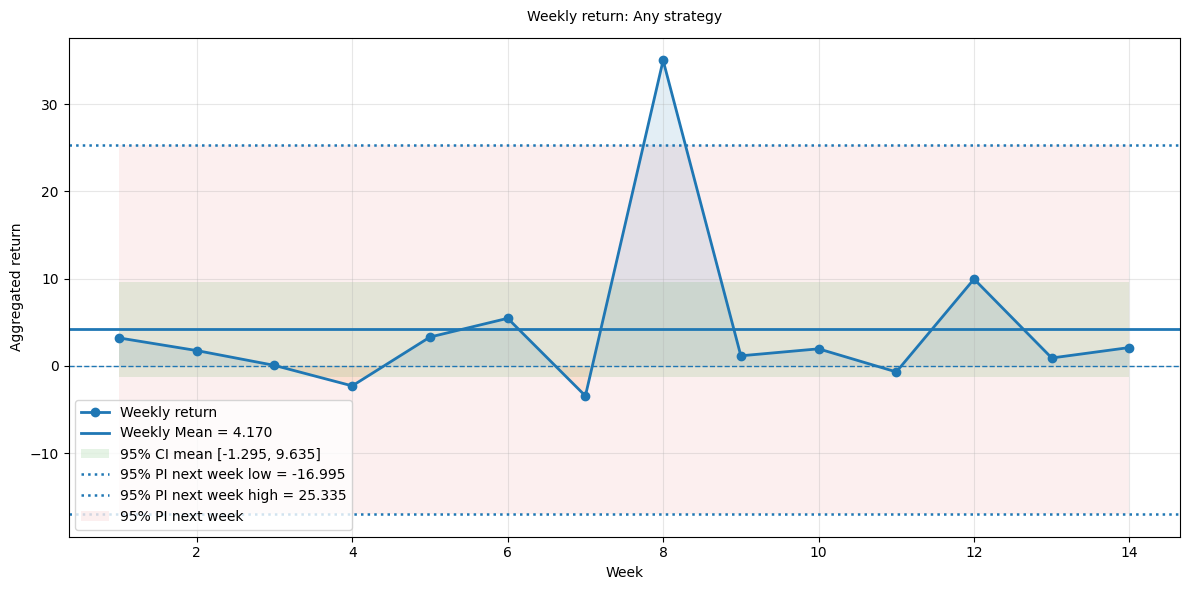

In [32]:
weekly_return, stats = analyze_strategies(df, print_pi=True)

In [33]:
weekly_return

week
1     3.20
2     1.75
3     0.05
4    -2.30
5     3.30
6     5.45
7    -3.45
8    35.03
9     1.15
10    1.95
11   -0.70
12    9.95
13    0.90
14    2.10
Name: return, dtype: float64

95% PI è la probabilità che il ritorno della prossima settimana sia compreso fra PI low e PI high
### Note:
1. Ritorno medio è positivo ma a estremo inferiore CI negativo -> non è detto che il vero valor medio del ritorno settimanale è > 0
2. 95% PI estremamente variabile

## Approccio 2: scommetto i mercati che si comportano meglio su tutti i campionati

In [35]:
strategy_df = get_best_strategies(df)
strategy_df

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
BTTS,2.41,8.49,4.64,8.05,65,0.78
Over 1.5 (M2-X),1.14,1.96,7.36,6.38,103,0.81
CN Home (Asiatic),0.47,0.95,2.79,2.73,39,0.70
Goal HT,0.39,1.75,5.29,3.71,74,0.79
Over 0.5 HT (Live),0.26,1.25,4.64,3.92,65,0.82
DNB 1,0.25,2.09,6.93,4.23,97,0.72
Win 1,0.25,0.94,1.93,1.44,27,0.76
Multigoal 1-2 Home,0.23,1.13,1.07,1.10,15,0.78
Win x2 HT,0.15,1.51,1.93,1.49,27,0.58
DNB 1 Optuna,0.10,0.71,1.79,4.38,25,0.72


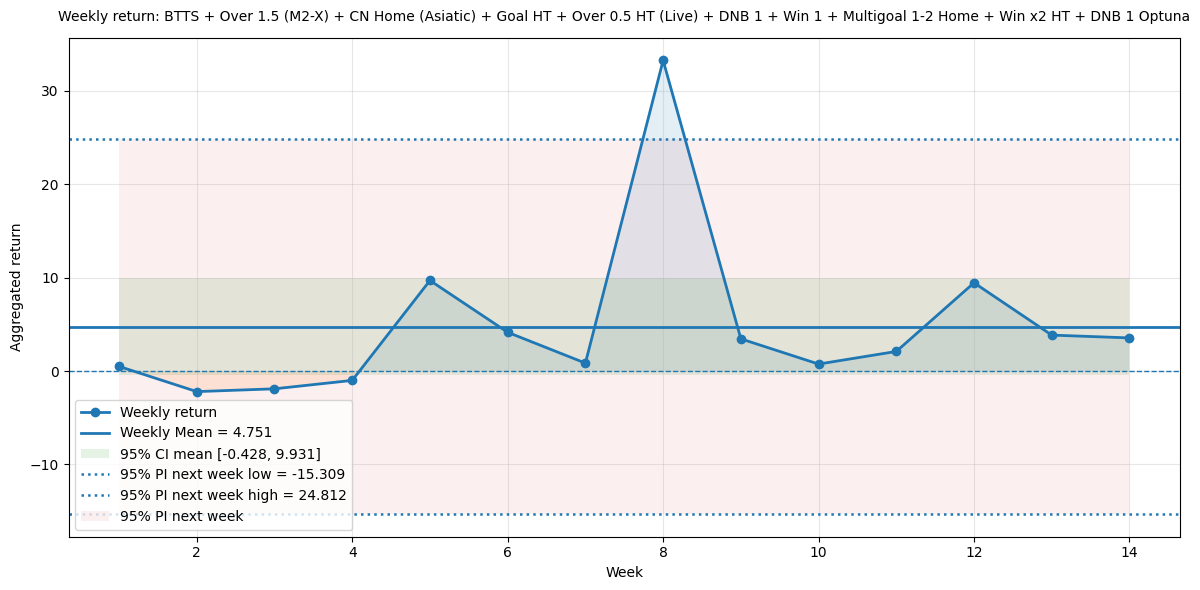

In [36]:
# Tolgo mercati con ritorno medio settimanale negativo e analizzo le strategie
best_strategies = strategy_df[strategy_df["weekly_mean_return"] > 0].index.to_list()
weekly_return, stats = analyze_strategies(df, strategies=best_strategies, print_pi=True)

In [6]:
weekly_return

week
1     0.50
2    -2.20
3    -1.90
4    -1.00
5     9.70
6     4.15
7     0.85
8    33.27
9     3.45
10    0.75
11    2.10
12    9.45
13    9.80
14   12.90
Name: return, dtype: float64

### Note:
- Valor medio leggermente più alto ma meno confidente (CI mean)
- Intervallo PI maggiore -> più volatile
- Andando a vedere sopra, BTTS è quello che porta più ritorno ma è quello più volatile (ha performato particolarmente bene in week 7), provo a toglierlo

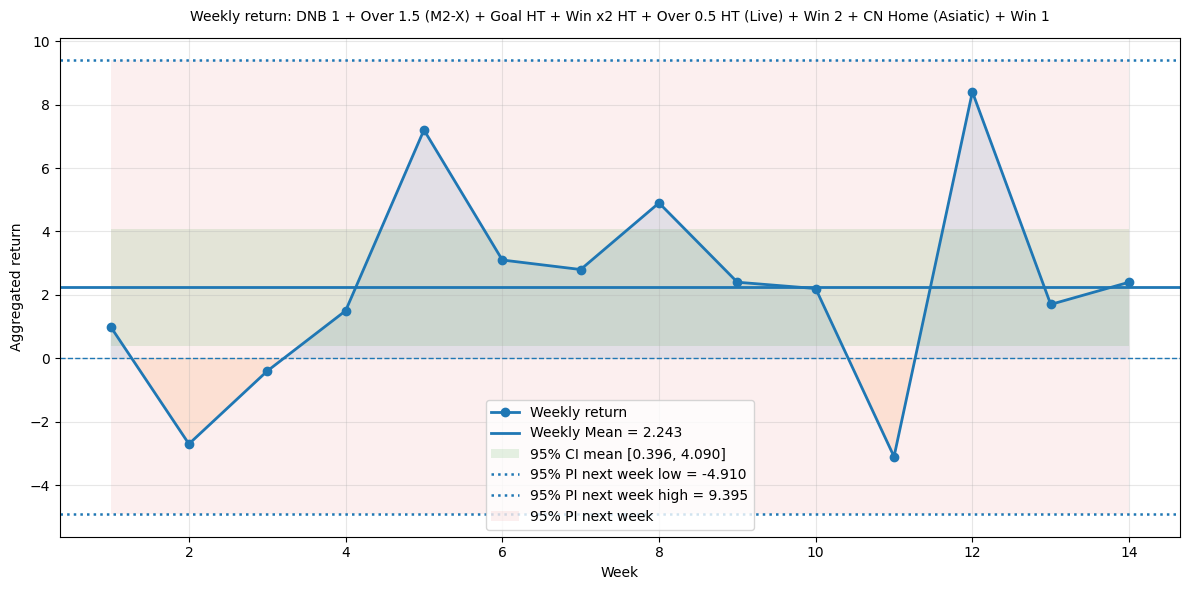

In [37]:
weekly_return, stats = analyze_strategies(df, strategies=['DNB 1', 'Over 1.5 (M2-X)', 'Goal HT', 'Win x2 HT', 'Over 0.5 HT (Live)', 'Win 2', 'CN Home (Asiatic)', 'Win 1'], print_pi=True)

In [38]:
weekly_return

week
1     1.00
2    -2.70
3    -0.40
4     1.50
5     7.20
6     3.10
7     2.80
8     4.90
9     2.40
10    2.20
11   -3.10
12    8.40
13    1.70
14    2.40
Name: return, dtype: float64

### Note:
- ritorno medio minore ma CI low > 0 -> al 95% il ritorno medio settimanale è positivo
- PI molto meno variabile

## Approccio 3: scommetto solo sui campionati migliori

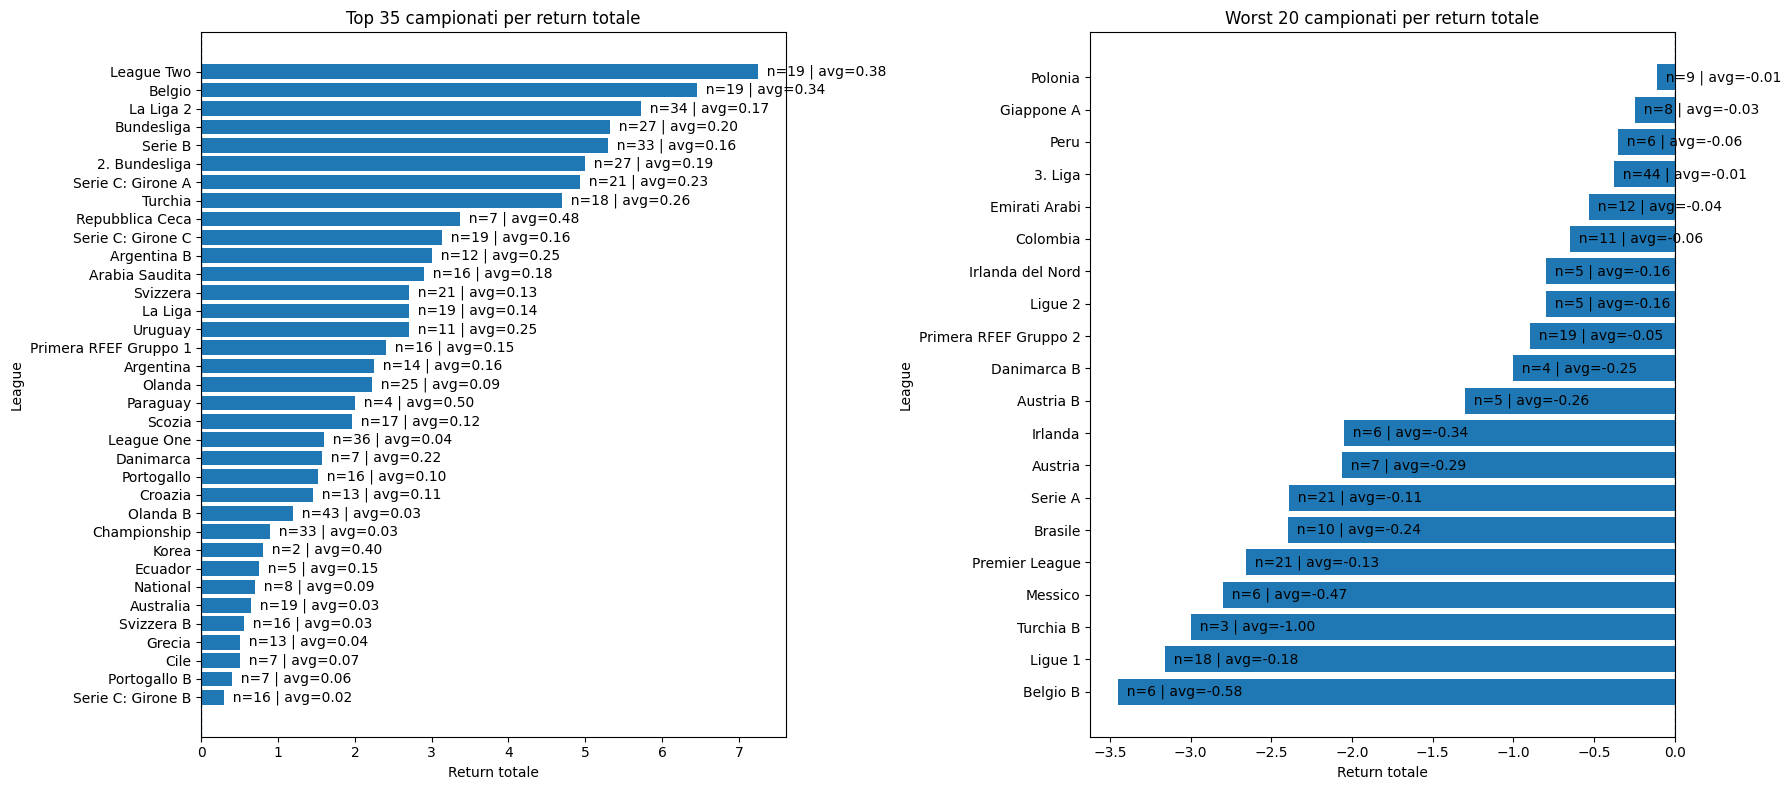

In [46]:
best_leagues = get_best_leagues(df)

In [47]:
threshold = best_leagues["n_matches"].quantile(q=0.1)
print(f"Threshold: {threshold}")
league_list = list(best_leagues[best_leagues["n_matches"] > threshold].index)

Threshold: 7.0


In [48]:
# Vedo quali sono le migliori scommesse per i campionati con ritorno positivo (considero solo campionati grafico a sx)
get_best_strategies(df, leagues=league_list)

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
BTTS,1.53,4.23,2.71,4.13,38,0.84
Over 1.5 (M2-X),1.14,1.38,5.43,4.98,76,0.85
DNB 1 Optuna,0.90,1.84,1.07,2.68,15,0.78
Goal HT,0.88,1.29,4.00,2.56,56,0.85
Over 1.5 Optuna,0.62,1.03,4.43,10.85,62,0.89
Win x2 HT,0.48,1.54,1.64,1.39,23,0.70
DNB 1,0.46,1.89,5.14,3.58,72,0.82
Over 0.5 HT (Live),0.42,0.66,2.86,2.59,40,0.88
Win 1,0.41,0.77,1.29,0.88,18,0.82
CN Home (Asiatic),0.27,1.17,2.14,2.23,30,0.73


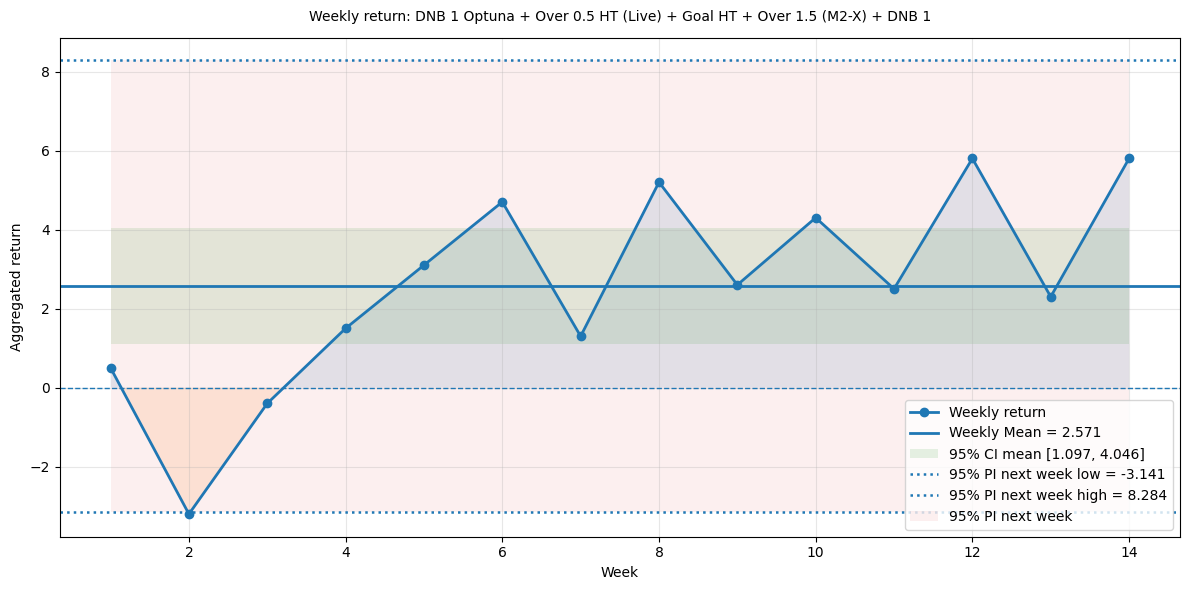

In [52]:
# Prendo le strategie migliori togliendo CN Home perchè ha ritorno negativo e BTTS per alta volatilità
best_strategies = ['DNB 1 Optuna', 'Over 0.5 HT (Live)', 'Goal HT', 'Over 1.5 (M2-X)', 'DNB 1']

weekly_return, stats_1 = analyze_strategies(df, strategies=best_strategies, leagues=league_list, print_pi=True)

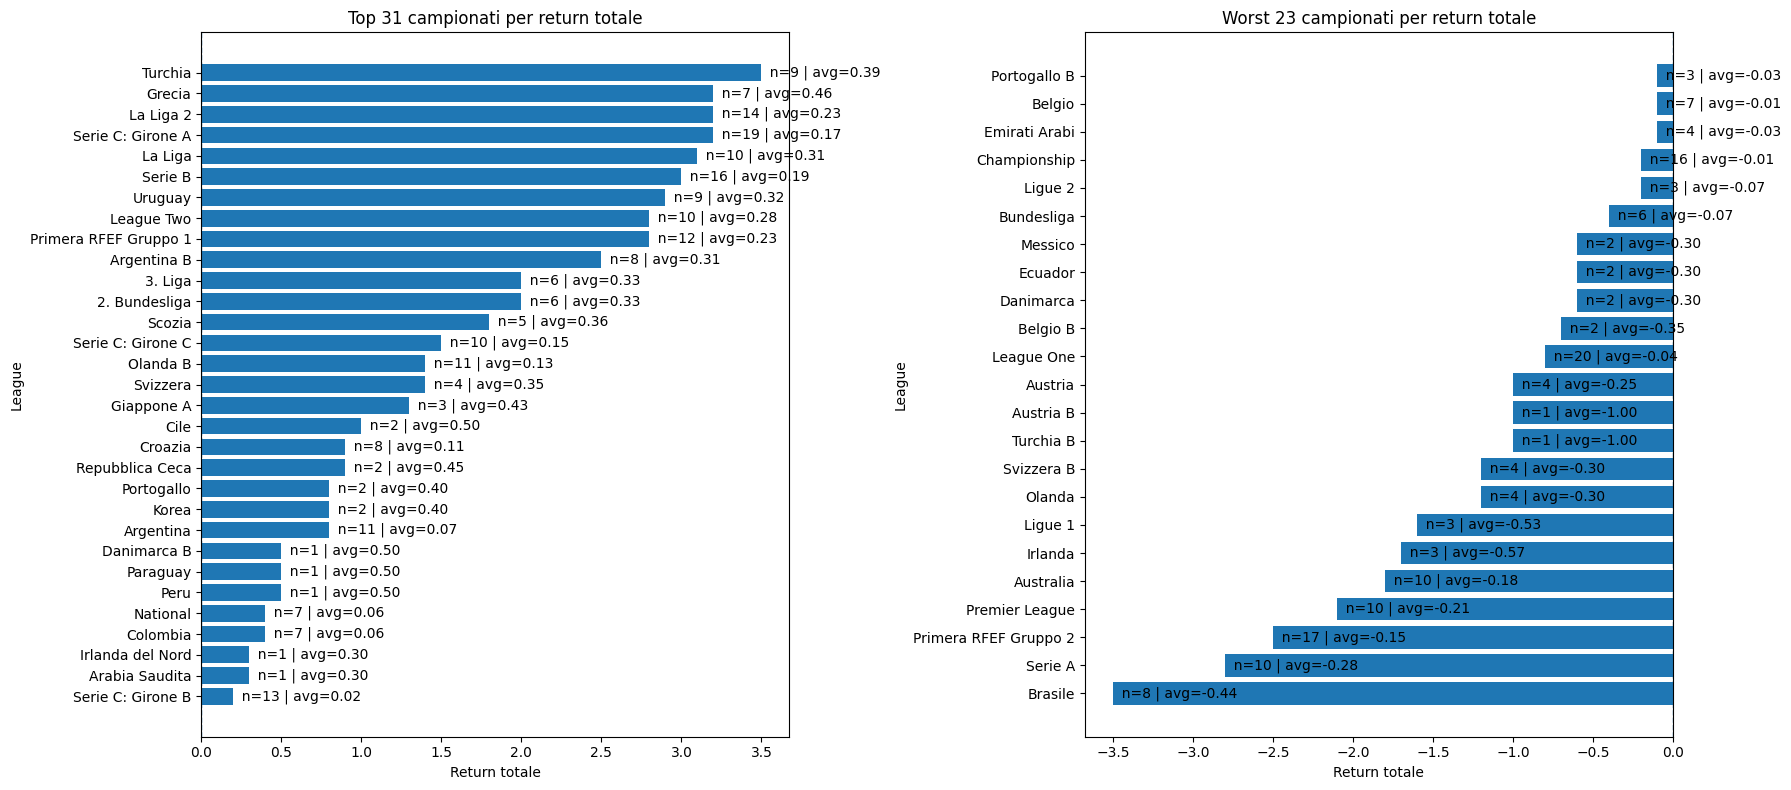

Threshold: 1.0


In [53]:
# Find the best leageus for the best strategies 
best_leagues = get_best_leagues(df, strategies=best_strategies)
threshold = best_leagues["n_matches"].quantile(q=0.1)
league_list = list(best_leagues[best_leagues["n_matches"] > threshold].index)

print(f"Threshold: {threshold}")

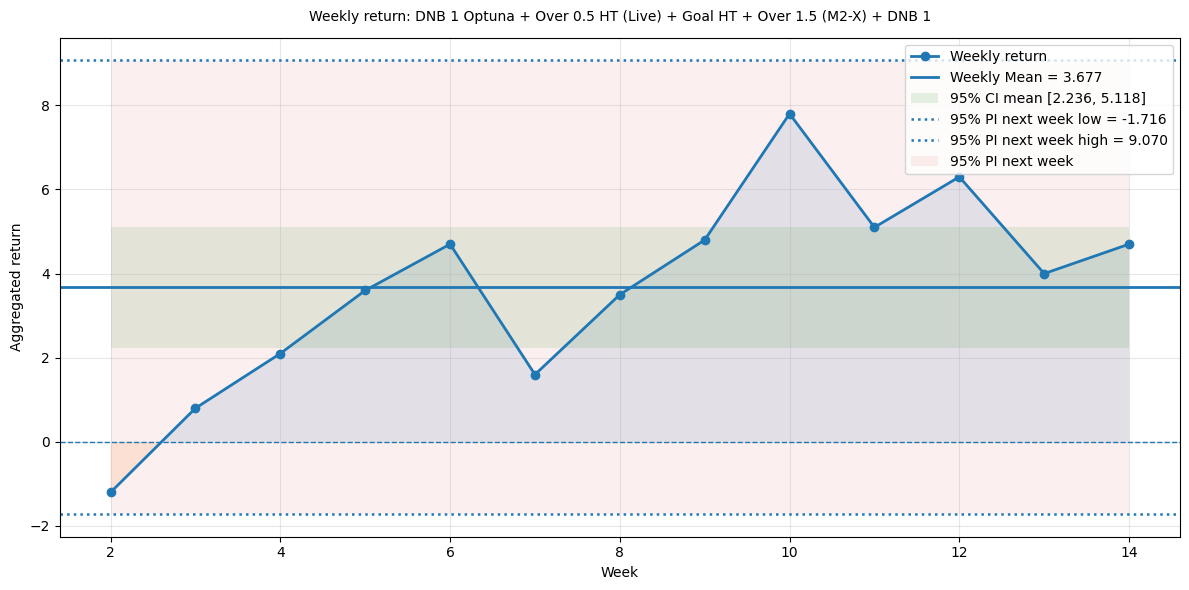

In [55]:
weekly_return, stats_2 = analyze_strategies(df, strategies=best_strategies, leagues=league_list, print_pi=True)

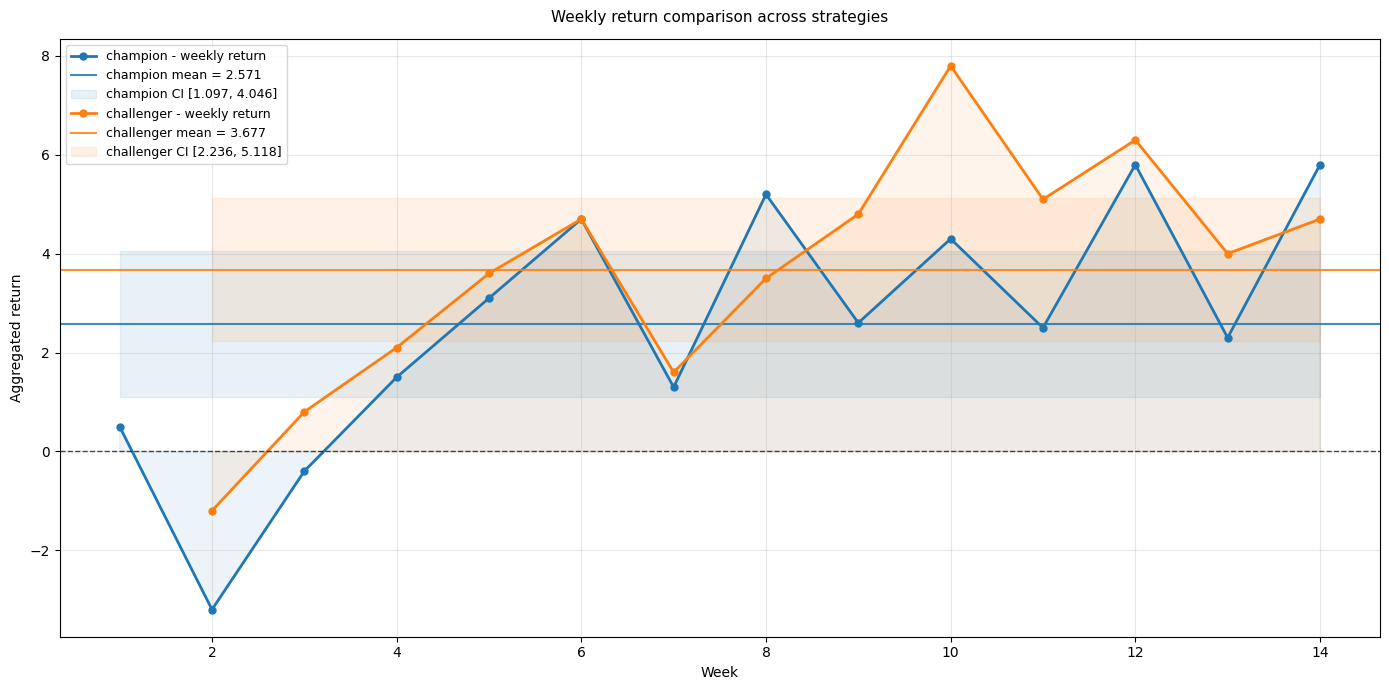

In [57]:
strategies_to_compare = {"champion": stats_1, "challenger": stats_2}

aggregated_data, summary_df = compare_strategies(
    df=df,
    strategies=strategies_to_compare,
    show_ci=True,
    show_pi=False
)

In [58]:
weekly_return

week
2    -1.20
3     0.80
4     2.10
5     3.60
6     4.70
7     1.60
8     3.50
9     4.80
10    7.80
11    5.10
12    6.30
13    4.00
14    4.70
Name: return, dtype: float64

In [59]:
summary_df

,label,strategy,leagues,n_weeks,expected_bets_per_week,mean_weekly_agg_return,std_weekly_agg_return,sem,ci_low,ci_high,pi_low,pi_high
0,champion,"[DNB 1 Optuna, Over 0.5 HT (Live), Goal HT, Ov...","[League Two, Belgio, La Liga 2, Bundesliga, Se...",14,15,2.57,2.55,0.68,1.10,4.05,-3.14,8.28
1,challenger,"[DNB 1 Optuna, Over 0.5 HT (Live), Goal HT, Ov...","[Turchia, La Liga 2, Grecia, Serie C: Girone A...",13,14,3.68,2.39,0.66,2.24,5.12,-1.72,9.07


In [65]:
set(summary_df.iloc[1]['strategy'])

{'DNB 1', 'DNB 1 Optuna', 'Goal HT', 'Over 0.5 HT (Live)', 'Over 1.5 (M2-X)'}

### Note:
- Ritorno medio più alto del precedente ma ancora minore del primo
- Confidenza molto più alta sia del primo che del secondo (CI low 1.5 vuol dire che il valor medio sul lungo periodo è almeno 1.53 al 95% di confidenza)
- Variabilità sulla settimana (PI) maggiore di prima ma più spostato verso l'alto